# Game and Success in Students: A Data Mining Project

 This project analyzes the relationship between students' gaming habits, family background, and academic grades.

In [8]:
import os

os.makedirs("Images", exist_ok=True)

In [9]:
import pandas as pd

# Load the CSV file into a dataframe
df = pd.read_csv("gameandgrade.csv")

# Show the first 5 rows
print(df.head())

# Show how many rows and columns we have
print(df.shape)

# Check for missing values in each column
print(df.isnull().sum())

# Remove extra hidden spaces from column names
df.columns = df.columns.str.strip()

# Rename NSex to Sex
df = df.rename(columns={"NSex": "Sex"})

# Print the column names to verify
print(df.columns)

# Check the data type of each column
print(df.dtypes)

# Fix typo in Grade column, for example 92..00 -> 92.00
df["Grade"] = df["Grade"].str.replace("..", ".", regex=False)

# Remove any letters from Grade column, for example 88.00N -> 88.00
df["Grade"] = df["Grade"].str.replace(r"[a-zA-Z]", "", regex=True)

# Convert Grade from text to number
df["Grade"] = pd.to_numeric(df["Grade"], errors="coerce")

# Remove rows where Grade could not be converted
df = df.dropna(subset=["Grade"])

# Confirm Grade is now a number
print(df["Grade"].dtype)

# Save the cleaned data to a new CSV file
df.to_csv("gameandgrade_cleaned.csv", index=False)

print("Cleaned file saved!")

   NSex  School Code  Playing Years  Playing Often  Playing Hours  \
0     0            1              1              2              1   
1     1            1              1              3              1   
2     0            1              0              0              0   
3     0            1              3              5              1   
4     1            1              1              1              2   

   Playing Games  Parent Revenue  Father Education  Mother Education  Grade  
0              1               4                 4                 5  77.50  
1              1               1                 3                 3  83.00  
2              0               1                 3                 3  80.00  
3              1               2                 2                 3  45.00  
4              1               1                 3                 4  85.00  
(770, 10)
NSex                0
School Code         0
Playing Years       0
Playing Often       0
Playing Hours      

Dataset shape: (770, 10)
   Sex  School Code  Playing Years  Playing Often  Playing Hours  \
0    0            1              1              2              1   
1    1            1              1              3              1   
2    0            1              0              0              0   
3    0            1              3              5              1   
4    1            1              1              1              2   

   Playing Games  Parent Revenue  Father Education  Mother Education  Grade  
0              1               4                 4                 5   77.5  
1              1               1                 3                 3   83.0  
2              0               1                 3                 3   80.0  
3              1               2                 2                 3   45.0  
4              1               1                 3                 4   85.0  

Correlation with Grade:
Grade               1.000000
Mother Education    0.352787
Father Educatio

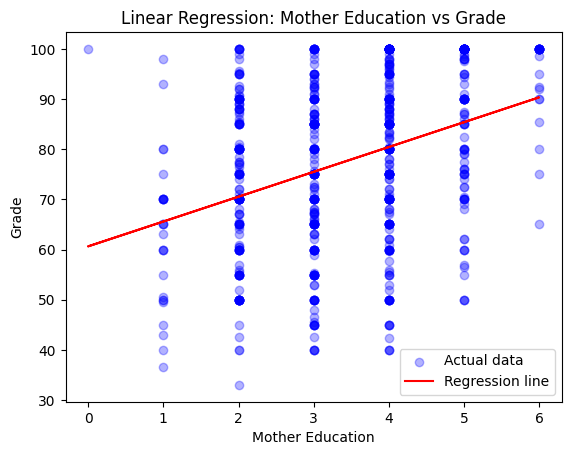


Multiple Regression Results:
  R² Score: 0.2164
  Coefficients:
    Sex: -3.3253
    School Code: 1.0565
    Playing Years: 0.1168
    Playing Hours: -0.7440
    Playing Games: -2.1146
    Parent Revenue: -0.0268
    Father Education: 2.2123
    Mother Education: 3.4404


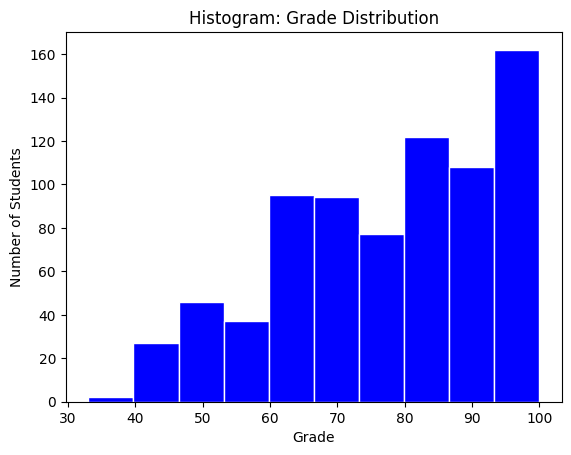


Clustering Results:
Cluster
1    330
0    283
2    157
Name: count, dtype: int64

Average Grade per Cluster:
Cluster
0    72.82
1    93.27
2    52.89
Name: Grade, dtype: float64


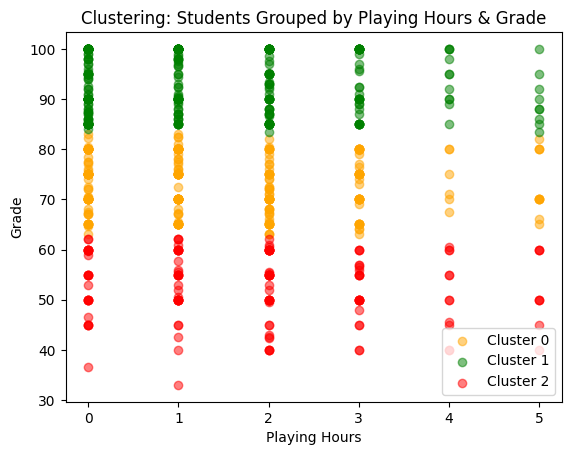


Sampling Results:
  Full dataset average Grade: 77.52
  Sample average Grade:       77.60

PCA Results:
  Component 1: 35.52% (cumulative: 35.52%)
  Component 2: 17.97% (cumulative: 53.48%)
  Component 3: 12.95% (cumulative: 66.44%)
  Component 4: 10.43% (cumulative: 76.86%)
  Component 5: 7.79% (cumulative: 84.66%)
  Component 6: 6.36% (cumulative: 91.02%)
  Component 7: 4.74% (cumulative: 95.76%)
  Component 8: 2.73% (cumulative: 98.50%)
  Component 9: 1.50% (cumulative: 100.00%)


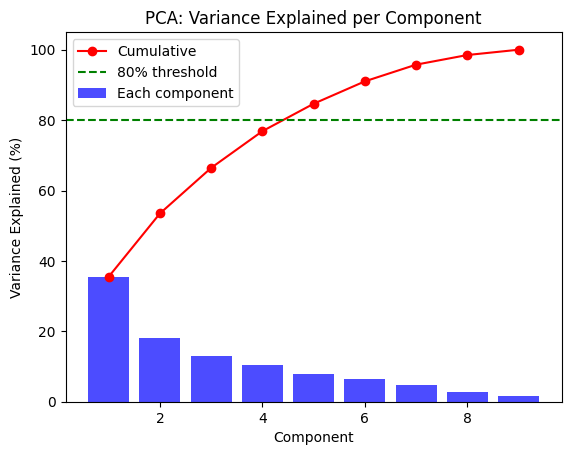

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the cleaned data
df = pd.read_csv("gameandgrade_cleaned.csv")
print("Dataset shape:", df.shape)
print(df.head())

# ── 1. ATTRIBUTE SUBSET SELECTION ──────────────────────────────────────────
# Check how much each column is related to Grade
# Values close to 1 or -1 = strong relationship
# Values close to 0 = weak relationship (not useful)
correlation = df.corr(numeric_only=True)["Grade"].sort_values(ascending=False)
print("\nCorrelation with Grade:")
print(correlation)

# Remove Playing Often — correlation = 0.009 (basically useless)
df_reduced = df.drop(columns=["Playing Often"])
print("\nColumns after reduction:", df_reduced.shape)

# ── 2. LINEAR REGRESSION ───────────────────────────────────────────────────
# Predict Grade using Mother Education (strongest single predictor)
X = df[["Mother Education"]]
y = df["Grade"]

model = LinearRegression()
model.fit(X, y)

print("\nLinear Regression Results:")
print(f"  Coefficient: {model.coef_[0]:.4f}")
print(f"  Intercept:   {model.intercept_:.4f}")
print(f"  Formula: Grade = {model.intercept_:.2f} + ({model.coef_[0]:.2f} x Mother Education)")

# Plot linear regression
plt.scatter(X, y, color="blue", alpha=0.3, label="Actual data")
plt.plot(X, model.predict(X), color="red", label="Regression line")
plt.xlabel("Mother Education")
plt.ylabel("Grade")
plt.title("Linear Regression: Mother Education vs Grade")
plt.legend()
plt.savefig("Images/Linear_Regression.png")
plt.show()

# ── 3. MULTIPLE REGRESSION ─────────────────────────────────────────────────
# Use all columns together to predict Grade
X_multi = df_reduced.drop(columns=["Grade"])
y = df["Grade"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\nMultiple Regression Results:")
print(f"  R² Score: {model_multi.score(X_multi, y):.4f}")
print("  Coefficients:")
for col, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"    {col}: {coef:.4f}")

# ── 4. HISTOGRAM ANALYSIS ──────────────────────────────────────────────────
# Shows the distribution of grades across all students
plt.hist(df["Grade"], bins=10, color="blue", edgecolor="white")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Histogram: Grade Distribution")
plt.savefig("Images/Histogram.png")
plt.show()

# ── 5. CLUSTERING (K-Means) ────────────────────────────────────────────────
# Group students into 3 clusters based on Playing Hours and Grade
X_cluster = df[["Playing Hours", "Grade"]]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster)

print("\nClustering Results:")
print(df["Cluster"].value_counts())
print("\nAverage Grade per Cluster:")
print(df.groupby("Cluster")["Grade"].mean().round(2))

# Plot clusters
colors = ["orange", "green", "red"]
for i in range(3):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(cluster_data["Playing Hours"], cluster_data["Grade"],
                color=colors[i], alpha=0.5, label=f"Cluster {i}")
plt.xlabel("Playing Hours")
plt.ylabel("Grade")
plt.title("Clustering: Students Grouped by Playing Hours & Grade")
plt.legend()
plt.savefig("Images/Cluster.png")
plt.show()

# ── 6. SAMPLING ────────────────────────────────────────────────────────────
# Take 100 random students to represent the full dataset
sample = df.sample(n=100, random_state=42)
print("\nSampling Results:")
print(f"  Full dataset average Grade: {df['Grade'].mean():.2f}")
print(f"  Sample average Grade:       {sample['Grade'].mean():.2f}")

# ── 7. PCA ─────────────────────────────────────────────────────────────────
# Reduce 9 columns into fewer components while keeping most information
X_pca = df.drop(columns=["Grade", "Cluster"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA()
pca.fit(X_scaled)

print("\nPCA Results:")
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative += var * 100
    print(f"  Component {i+1}: {var*100:.2f}% (cumulative: {cumulative:.2f}%)")

# Plot PCA variance
variance = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(variance)
plt.bar(range(1, len(variance)+1), variance, color="blue", alpha=0.7, label="Each component")
plt.plot(range(1, len(variance)+1), cumulative, color="red", marker="o", label="Cumulative")
plt.axhline(80, color="green", linestyle="--", label="80% threshold")
plt.xlabel("Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA: Variance Explained per Component")
plt.legend()
plt.savefig("Images/Variance.png")
plt.show()

In [11]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the cleaned data
df = pd.read_csv("gameandgrade_cleaned.csv")

# ── 1. SELECT COLUMNS TO NORMALIZE ────────────────────────────────────────
# We normalize all feature columns (not Grade — that's our target)
feature_cols = ["Playing Years", "Playing Hours", "Playing Games",
                "Parent Revenue", "Father Education", "Mother Education"]

# ── 2. SHOW ORIGINAL VALUES ────────────────────────────────────────────────
print("BEFORE Normalization:")
print(df[feature_cols].head())
print("\nOriginal ranges:")
for col in feature_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

# ── 3. MIN-MAX NORMALIZATION ───────────────────────────────────────────────
# Scales all values to between 0 and 1
# Formula: (value - min) / (max - min)
# Used when we don't want any column to dominate due to larger numbers
mm_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[feature_cols] = mm_scaler.fit_transform(df[feature_cols])

print("\nAFTER Min-Max Normalization (all values between 0 and 1):")
print(df_minmax[feature_cols].head())

# ── 4. Z-SCORE STANDARDIZATION ────────────────────────────────────────────
# Scales all values to have mean=0 and standard deviation=1
# Formula: (value - mean) / std
# Used when data needs to follow a normal distribution (e.g. for PCA)
z_scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[feature_cols] = z_scaler.fit_transform(df[feature_cols])

print("\nAFTER Z-Score Standardization (mean=0, std=1):")
print(df_zscore[feature_cols].head())

# ── 5. COMPARE RESULTS ─────────────────────────────────────────────────────
print("\nNormalization Comparison (Playing Hours):")
print(f"  Original:  min={df['Playing Hours'].min()}, max={df['Playing Hours'].max()}")
print(f"  Min-Max:   min={df_minmax['Playing Hours'].min():.2f}, max={df_minmax['Playing Hours'].max():.2f}")
print(f"  Z-Score:   min={df_zscore['Playing Hours'].min():.2f}, max={df_zscore['Playing Hours'].max():.2f}")

print("\nNormalization complete!")

BEFORE Normalization:
   Playing Years  Playing Hours  Playing Games  Parent Revenue  \
0              1              1              1               4   
1              1              1              1               1   
2              0              0              0               1   
3              3              1              1               2   
4              1              2              1               1   

   Father Education  Mother Education  
0                 4                 5  
1                 3                 3  
2                 3                 3  
3                 2                 3  
4                 3                 4  

Original ranges:
  Playing Years: min=0, max=4
  Playing Hours: min=0, max=5
  Playing Games: min=0, max=2
  Parent Revenue: min=0, max=4
  Father Education: min=0, max=6
  Mother Education: min=0, max=6

AFTER Min-Max Normalization (all values between 0 and 1):
   Playing Years  Playing Hours  Playing Games  Parent Revenue  \
0          

In [12]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv("gameandgrade_cleaned.csv")

# Discretize Grade into letter grades
df["Grade Category"] = pd.cut(df["Grade"],
                               bins=[0, 50, 60, 70, 80, 90, 101],
                               labels=["F", "D", "C", "B", "A", "A+"])

# Show results
print("Grade Discretization:")
print(df["Grade Category"].value_counts().sort_index())

Grade Discretization:
Grade Category
F      69
D      78
C     139
B     143
A     156
A+    185
Name: count, dtype: int64


Class distribution:
Grade Category
F      69
D      78
C     139
B     143
A     156
A+    185
Name: count, dtype: int64

Training samples: 616
Testing samples:  154

KNN Classification Results (k=5):
Accuracy: 33.77%

Classification Report:
              precision    recall  f1-score   support

           A       0.23      0.23      0.23        30
          A+       0.50      0.56      0.53        41
           B       0.27      0.29      0.28        24
           C       0.38      0.52      0.44        25
           D       0.00      0.00      0.00        15
           F       0.33      0.11      0.16        19

    accuracy                           0.34       154
   macro avg       0.29      0.29      0.27       154
weighted avg       0.32      0.34      0.32       154


Best K: 7 with accuracy 37.01%


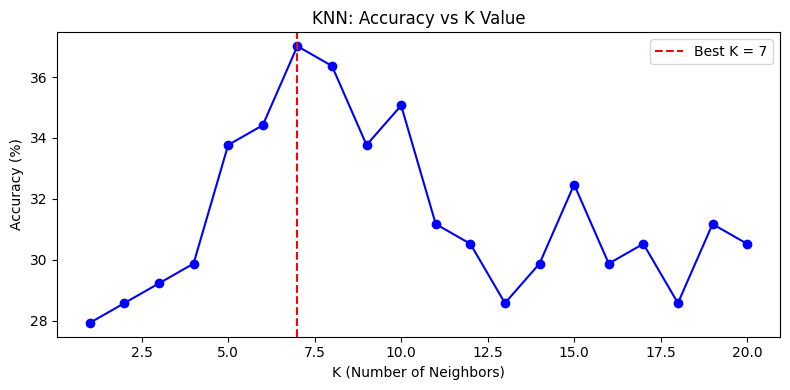

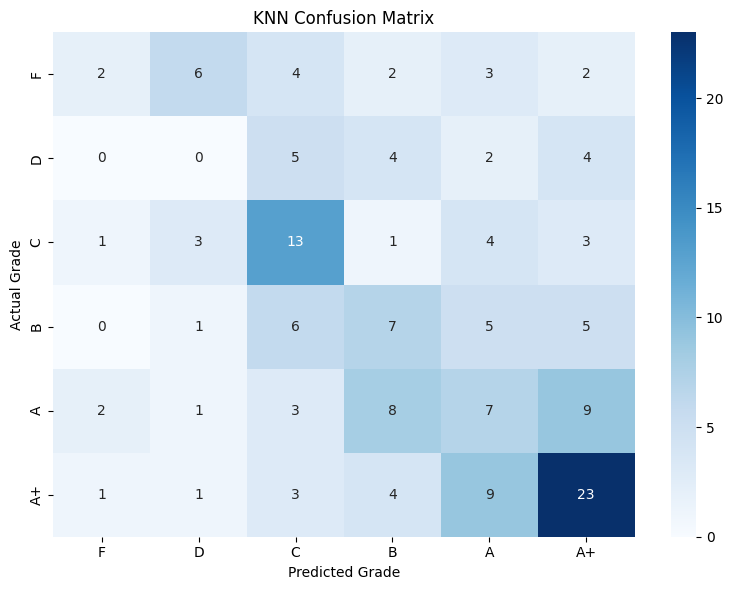


Classification complete!
Charts saved: KNN_Accuracy.png, KNN_Confusion_Matrix.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Load the cleaned data
df = pd.read_csv("gameandgrade_cleaned.csv")

# ── 1. CREATE TARGET VARIABLE ──────────────────────────────────────────────
# Convert continuous Grade into letter grade categories
# This is required for classification (needs categories, not numbers)
df["Grade Category"] = pd.cut(df["Grade"],
                               bins=[0, 50, 60, 70, 80, 90, 101],
                               labels=["F", "D", "C", "B", "A", "A+"])

# Remove any rows where Grade Category could not be assigned
df = df.dropna(subset=["Grade Category"])

print("Class distribution:")
print(df["Grade Category"].value_counts().sort_index())

# ── 2. PREPARE FEATURES AND TARGET ────────────────────────────────────────
# Remove Grade (we used it to make categories)
# Remove Playing Often (correlation = 0.009, not useful)
# Remove Grade Category (this is what we're predicting)
X = df.drop(columns=["Grade", "Grade Category", "Playing Often"])
y = df["Grade Category"]

# ── 3. NORMALIZE FEATURES ─────────────────────────────────────────────────
# KMeans uses distance — normalization ensures all features are equally weighted
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── 4. SPLIT DATA — 80% TRAINING, 20% TESTING ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# ── 5. TRAIN KNN MODEL (K=5) ───────────────────────────────────────────────
# K=5 is the standard starting point
# We test other values in Step 7 to find the best K
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# ── 6. EVALUATE THE MODEL ─────────────────────────────────────────────────
y_pred = knn.predict(X_test)

print("\nKNN Classification Results (k=5):")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── 7. FIND BEST K VALUE ───────────────────────────────────────────────────
# Test K from 1 to 20 and pick the one with highest accuracy
accuracies = []
k_range = range(1, 21)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

best_k = k_range[accuracies.index(max(accuracies))]
print(f"\nBest K: {best_k} with accuracy {max(accuracies) * 100:.2f}%")

# Plot accuracy vs K
plt.figure(figsize=(8, 4))
plt.plot(k_range, [a * 100 for a in accuracies], marker="o", color="blue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy (%)")
plt.title("KNN: Accuracy vs K Value")
plt.legend()
plt.tight_layout()
plt.savefig("Images/KNN_Accuracy.png")
plt.show()

# ── 8. CONFUSION MATRIX ───────────────────────────────────────────────────
# Shows how many students were correctly/incorrectly classified
cm = confusion_matrix(y_test, y_pred, labels=["F", "D", "C", "B", "A", "A+"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["F", "D", "C", "B", "A", "A+"],
            yticklabels=["F", "D", "C", "B", "A", "A+"])
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.savefig("Images/KNN_Confusion_Matrix.png")
plt.show()

print("\nClassification complete!")
print("Charts saved: KNN_Accuracy.png, KNN_Confusion_Matrix.png")

Dataset shape: (770, 10)
   Sex  School Code  Playing Years  Playing Often  Playing Hours  \
0    0            1              1              2              1   
1    1            1              1              3              1   
2    0            1              0              0              0   
3    0            1              3              5              1   
4    1            1              1              1              2   

   Playing Games  Parent Revenue  Father Education  Mother Education  Grade  
0              1               4                 4                 5   77.5  
1              1               1                 3                 3   83.0  
2              0               1                 3                 3   80.0  
3              1               2                 2                 3   45.0  
4              1               1                 3                 4   85.0  


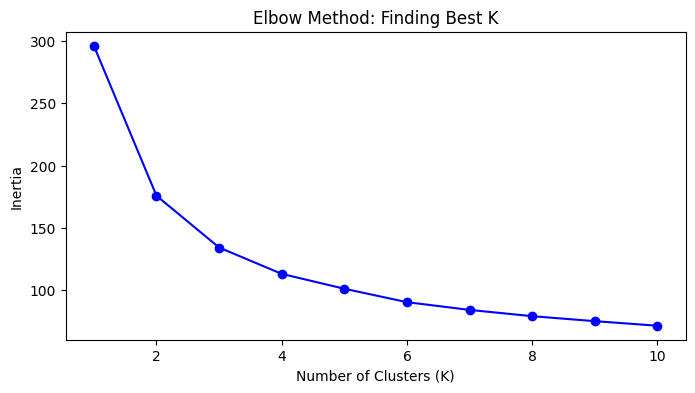


Number of students per cluster:
Cluster
0    324
1    219
2    227
Name: count, dtype: int64

Average values per cluster:
         Playing Hours  Playing Games  Playing Years  Mother Education  \
Cluster                                                                  
0                 1.70            1.0           1.40              3.30   
1                 2.72            1.0           3.49              3.58   
2                 0.00            0.0           0.00              3.40   

         Father Education  Grade  
Cluster                           
0                    3.59  75.70  
1                    3.86  76.07  
2                    3.76  81.51  


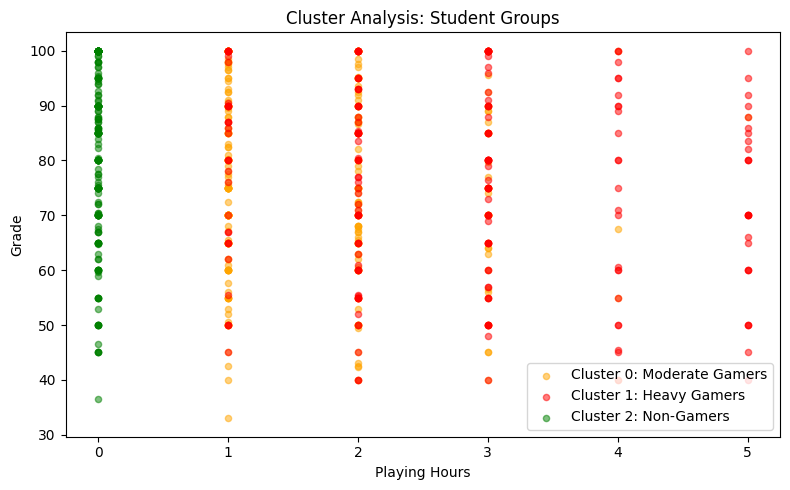


Cluster Analysis complete!
Charts saved: Elbow_Method.png, Cluster_Analysis.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load the cleaned data
df = pd.read_csv("gameandgrade_cleaned.csv")
print("Dataset shape:", df.shape)
print(df.head())

# ── 1. SELECT FEATURES ─────────────────────────────────────────────────────
# We use gaming habits + parental education + Grade
# Playing Often is excluded (correlation with Grade = 0.009, not useful)
features = ["Playing Hours", "Playing Games", "Playing Years",
            "Mother Education", "Father Education", "Grade"]

X = df[features]

# ── 2. NORMALIZE THE DATA ──────────────────────────────────────────────────
# KMeans uses distance to group students
# Without normalization, Grade (33-100) would dominate over Playing Hours (0-5)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. ELBOW METHOD — Find the best number of clusters ────────────────────
# We test K=1 to K=10 and look for where the curve flattens
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o", color="blue")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method: Finding Best K")
plt.savefig("Images/Elbow_Method.png")
plt.show()

# ── 4. APPLY KMEANS WITH K=3 ───────────────────────────────────────────────
# K=3 chosen from elbow curve — curve flattens after K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# ── 5. CLUSTER SUMMARY ─────────────────────────────────────────────────────
print("\nNumber of students per cluster:")
print(df["Cluster"].value_counts().sort_index())

print("\nAverage values per cluster:")
print(df.groupby("Cluster")[features].mean().round(2))

# Label clusters based on average Grade
# Cluster 0: Moderate Gamers  (avg Grade 75.70, avg Hours 1.70)
# Cluster 1: Heavy Gamers     (avg Grade 76.07, avg Hours 2.72)
# Cluster 2: Non-Gamers       (avg Grade 81.51, avg Hours 0.00)

# ── 6. VISUALIZE THE CLUSTERS ──────────────────────────────────────────────
colors = ["orange", "red", "green"]
labels = ["Cluster 0: Moderate Gamers",
          "Cluster 1: Heavy Gamers",
          "Cluster 2: Non-Gamers"]

plt.figure(figsize=(8, 5))
for i in range(3):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(cluster_data["Playing Hours"], cluster_data["Grade"],
                color=colors[i], alpha=0.5, s=20, label=labels[i])

plt.xlabel("Playing Hours")
plt.ylabel("Grade")
plt.title("Cluster Analysis: Student Groups")
plt.legend()
plt.tight_layout()
plt.savefig("Images/Cluster_Analysis.png")
plt.show()

print("\nCluster Analysis complete!")
print("Charts saved: Elbow_Method.png, Cluster_Analysis.png")